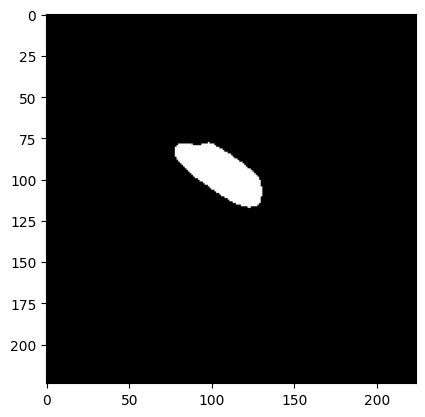

In [13]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

folder_path = "Raw_Data/nadirshail"  # Path to the folder

# Get a list of images
images = os.listdir(folder_path)

for img_name in images:
    img_path = os.path.join(folder_path, img_name)  # ✅ FIXED: Use full path

    if not os.path.isfile(img_path):  # ✅ Check if it's a valid file
        continue  

    # Load and process image
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)

    img = image.img_to_array(img)
    datagen = ImageDataGenerator(
        rotation_range=180,         # Random rotation up to 180 degrees
        width_shift_range=0.2,     # Random horizontal shift
        height_shift_range=0.2,    # Random vertical shift
        shear_range=0.1,           # Shear transformation
        zoom_range=0.2,            # Random zoom
        horizontal_flip=True,      # Flip images horizontally
        vertical_flip=False,       # No vertical flipping (for natural images)
        brightness_range=[0.8, 1.2], # Adjust brightness randomly
        fill_mode='nearest'        # Fill pixels with nearest values
    )


    input_batch = img.reshape(1, 224, 224, 3)
    cnt = 0
    directory = "Aug_Data/nadirshail"

    # ✅ Create the output directory if it doesn't exist
    os.makedirs(directory, exist_ok=True)  

    # Generate augmented images
    for output in datagen.flow(input_batch, batch_size=1, save_to_dir=directory, save_prefix="aug_", save_format="png"):
        cnt += 1
        if cnt == 20:
            break
